# Analyse exploratoire des données de ventes d'un supermaché

## Importation des librairies et vue d'ensemble du jeu de données

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
sales = pd.read_csv('Supermarket Sales 2.csv')

In [4]:
sales.tail()

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating
5048,12/31/2024,Manhattan,Normal,Female,Food & Beverages,6.71,10,Cash,5.9
5049,12/31/2024,Brooklyn,Normal,Male,Food & Beverages,6.79,9,Credit card,4.8
5050,12/31/2024,Queens,Member,Male,Electronics,85.05,7,Ewallet,4.4
5051,12/31/2024,Manhattan,Member,Female,Sports & Travel,54.64,10,Credit card,4.8
5052,12/31/2024,Queens,Normal,Female,Health & Beauty,49.75,7,Cash,5.8


In [5]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 5053 entries, 0 to 5052
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5053 non-null   str    
 1   Branch         5053 non-null   str    
 2   Customer type  5053 non-null   str    
 3   Gender         5053 non-null   str    
 4   Product line   5053 non-null   str    
 5   Unit price     5053 non-null   float64
 6   Quantity       5053 non-null   int64  
 7   Payment        5053 non-null   str    
 8   Rating         5053 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 355.4 KB


In [6]:
val_manquantes = sales.isnull().sum()

print( val_manquantes)

Date             0
Branch           0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Payment          0
Rating           0
dtype: int64


## Analyse univariée 


### Distributions des variables quantitatives

In [7]:
sales['Date'] = pd.to_datetime(sales['Date'])
var_quanti = sales.select_dtypes(include=['number']).columns
print(var_quanti)

Index(['Unit price', 'Quantity', 'Rating'], dtype='str')


In [8]:
sales[var_quanti].describe()

,Unit price,Quantity,Rating
count,5053.000000,5053.000000,5053.000000
mean,39.692988,4.593509,6.884029
std,29.557474,2.787934,1.710245
min,2.010000,1.000000,3.000000
25%,11.630000,2.000000,5.600000
50%,33.900000,4.000000,7.100000
75%,64.940000,7.000000,8.200000
max,99.960000,10.000000,10.000000


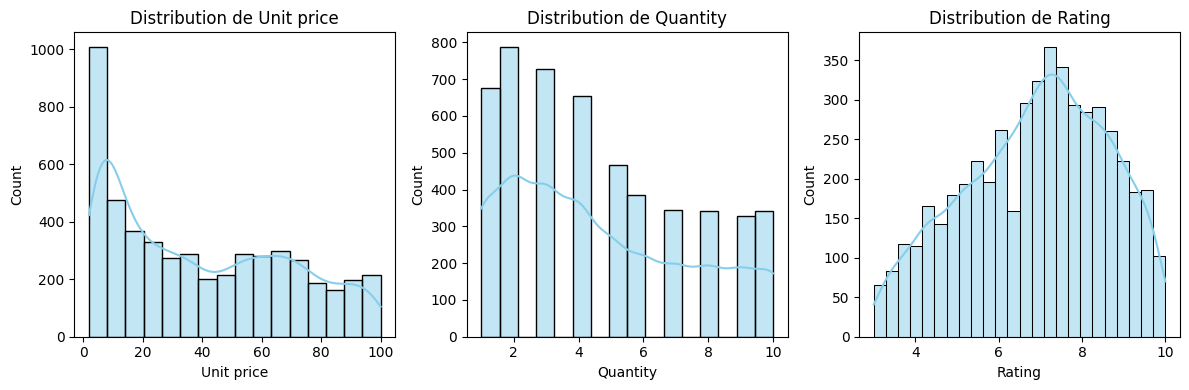

In [17]:

plt.figure(figsize=(12,4))

for i, var in enumerate(var_quanti, 1):
    plt.subplot(1,3,i)
    sns.histplot(sales[var], kde=True, color='skyblue')
    plt.title(f'Distribution de {var}')

plt.tight_layout()
plt.show()


-On voit que la distribution des prix est asymetrique à droite : **il y a beaucoup plus de produits à faibles valeurs**.  
-Concernant la quantité on a une distribution beaucoup plus homogéne : **les quantités vendues varient entre 2 et 10**.  
-Enfin pour la distribution de la variable Rating, elle est relativement symétrique et centrée autour de 7 : **La plupart des évaluations se situent entre 6 et 8, ce qui indique un niveau de satisfaction globalement élevé des clients**.

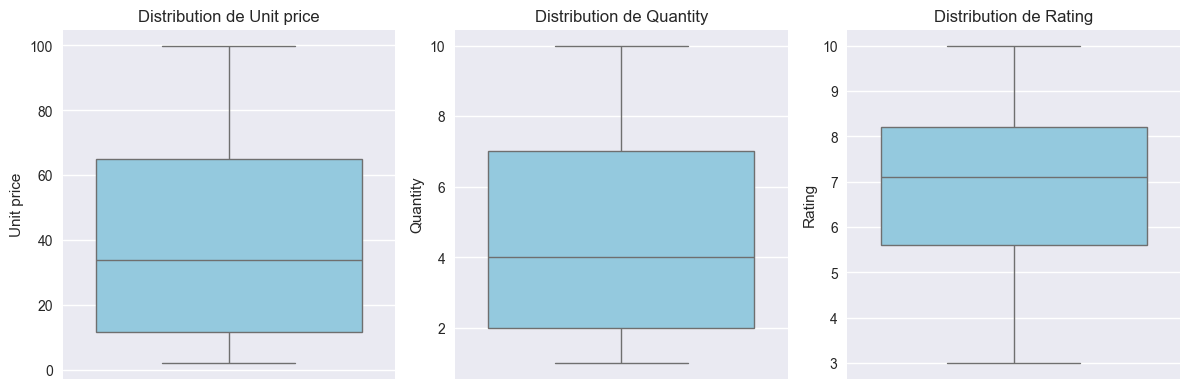

In [9]:
plt.figure(figsize=(12,4))

for i, var in enumerate(var_quanti, 1):
    plt.subplot(1,3,i)
    sns.boxplot(sales[var], color='skyblue')
    plt.title(f'Distribution de {var}')

plt.tight_layout()
plt.show()

Les boites à moustaches ne montrent aucunes valeurs extremes, ce qui signifie que les valeurs de otre base de données sont cohérentes. 

In [89]:
corré = sales[var_quanti].corr()
print(corré)

            Unit price  Quantity    Rating
Unit price    1.000000  0.050998 -0.003494
Quantity      0.050998  1.000000 -0.104483
Rating       -0.003494 -0.104483  1.000000


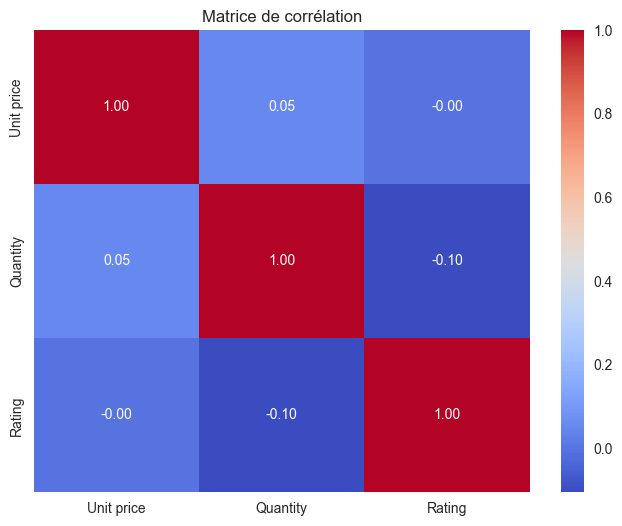

In [90]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corré,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()

Les corrélations entre les variables numériques sont toutes 
proches de 0 . Cela signifie que :
- Le prix unitaire n'influence pas la quantité achetée
- La satisfaction (Rating) est indépendante du prix
- Les clients achètent autant de produits chers que bon marché

### distribution des variables qualitatives


In [11]:

var_qualis = sales.select_dtypes(include='string').columns
print(var_qualis)

Index(['Branch', 'Customer type', 'Gender', 'Product line', 'Payment'], dtype='str')


C:\Users\diopd\AppData\Local\Temp\ipykernel_30384\2646399573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=sales[var], order=sales[var].value_counts().index, palette='Set2')
C:\Users\diopd\AppData\Local\Temp\ipykernel_30384\2646399573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=sales[var], order=sales[var].value_counts().index, palette='Set2')
C:\Users\diopd\AppData\Local\Temp\ipykernel_30384\2646399573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=sales[var], order=sales[var].value_counts().index, palette='Se

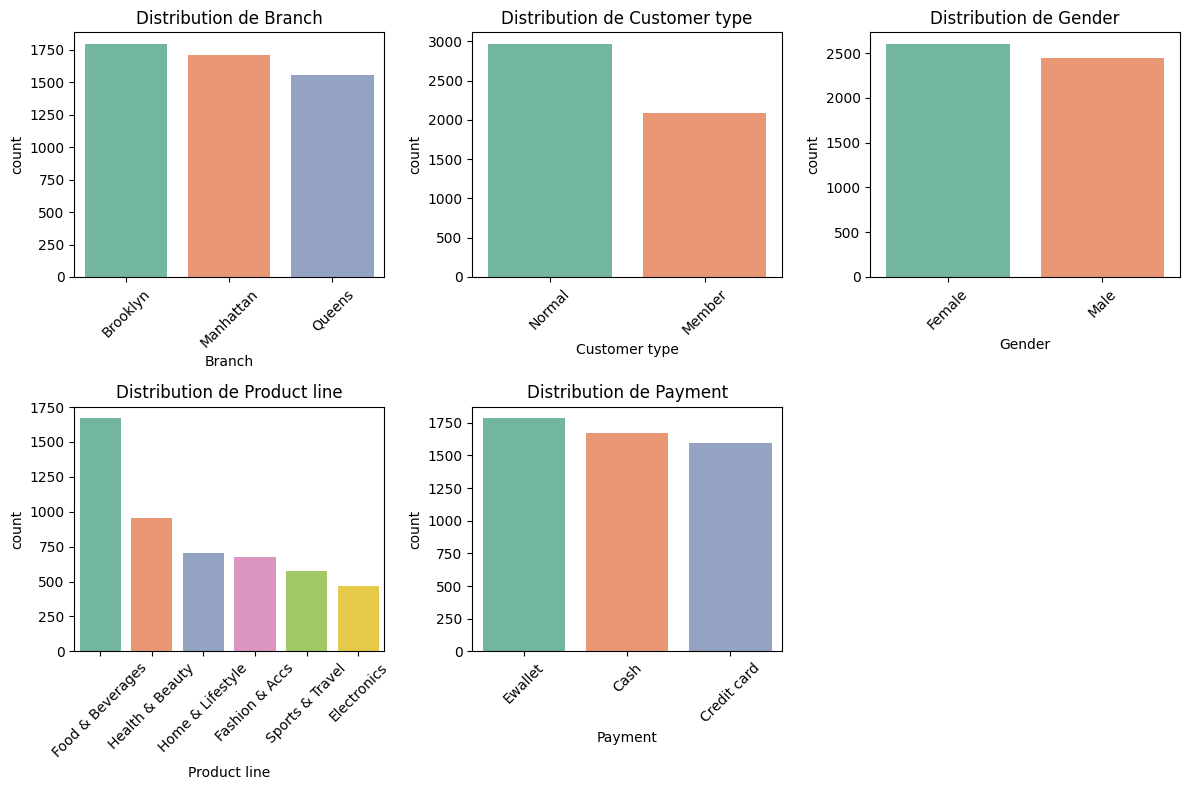

In [12]:
plt.figure(figsize=(12,8))

for i, var in enumerate(var_qualis, 1): 
    
    plt.subplot(2,3,i)
    sns.countplot(x=sales[var], order=sales[var].value_counts().index, palette='Set2')
    plt.title(f'Distribution de {var}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analyse bivariée 

### Lien entre chiffre d'affaire et les différentes caractéristiques du supermarché

In [35]:
sales ['CA'] = sales['Quantity']*sales['Unit price']
print(sales["CA"].mean().round())

187.0


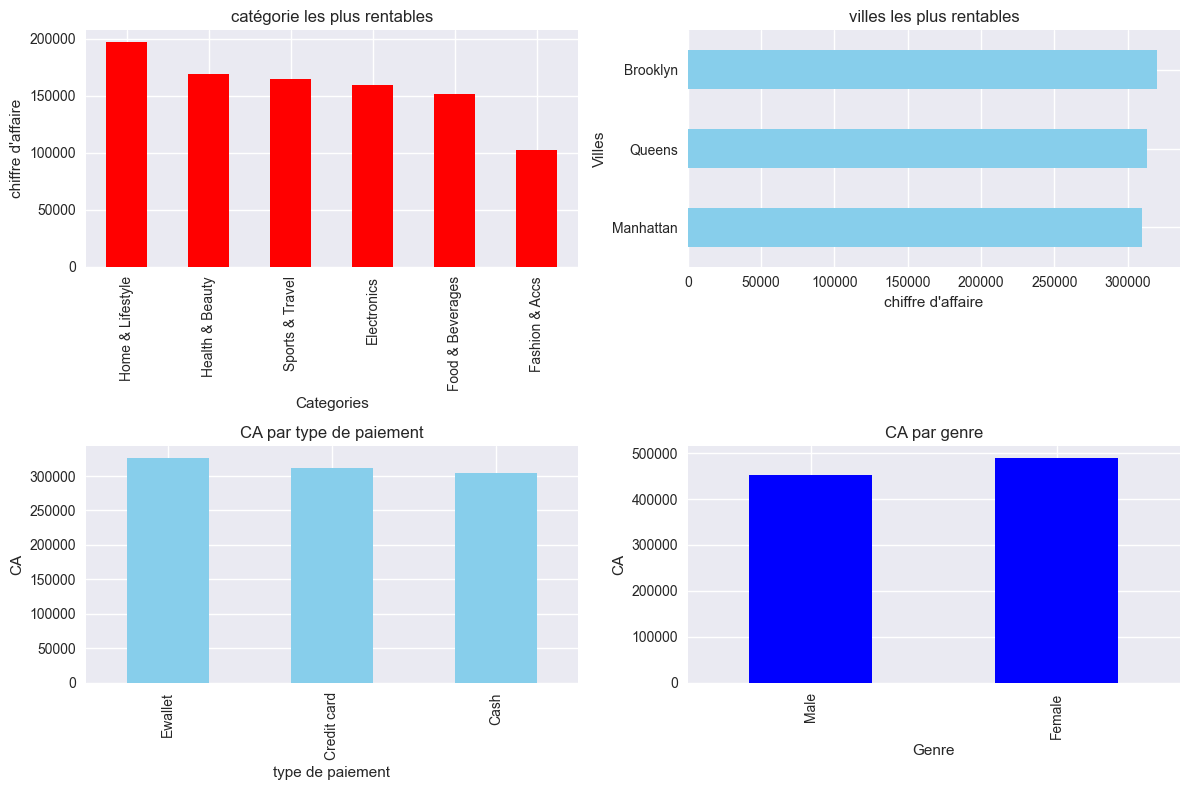

In [23]:
plt.figure(figsize=(12,8))


plt.subplot (2,2,1)
prod_rentables = sales.groupby('Product line')['CA'].sum().sort_values(ascending=False)
prod_rentables.plot(kind= 'bar', color="red")
plt.title('catégorie les plus rentables')
plt.xlabel('Categories')
plt.ylabel("chiffre d'affaire")

plt.subplot (2,2,2)
villes_rentables = sales.groupby('Branch')['CA'].sum().sort_values()
villes_rentables.plot(kind= 'barh', color='skyblue')
plt.title('villes les plus rentables')
plt.ylabel('Villes')
plt.xlabel("chiffre d'affaire")

plt.subplot (2,2,3)
paiement = sales.groupby('Payment')['CA'].sum().sort_values(ascending=False)
paiement.plot(kind='bar', color= "skyblue")
plt.title('CA par type de paiement')
plt.ylabel('CA')
plt.xlabel("type de paiement")

plt.subplot (2,2,4)
CA_genre = sales.groupby('Gender')['CA'].sum().sort_values()
CA_genre.plot(kind= 'bar', color='blue')
plt.title('CA par genre')
plt.ylabel('CA')
plt.xlabel("Genre")



plt.tight_layout()
plt.show()

En analysant les graphiques concernant le chiffre d'affaire, on peut voir la catégorie de produits la plus rentable (Home and lifestyle). Donc meme si le supermarché vend plus d'articles concernant l'alimentation, sa catégorie la plus rentable reste les produits liés à la maison et au mode de vie quotidien (probablement expliqué par le fait que ces produits sont plus chers : on pourra le voir grace à un graphique)

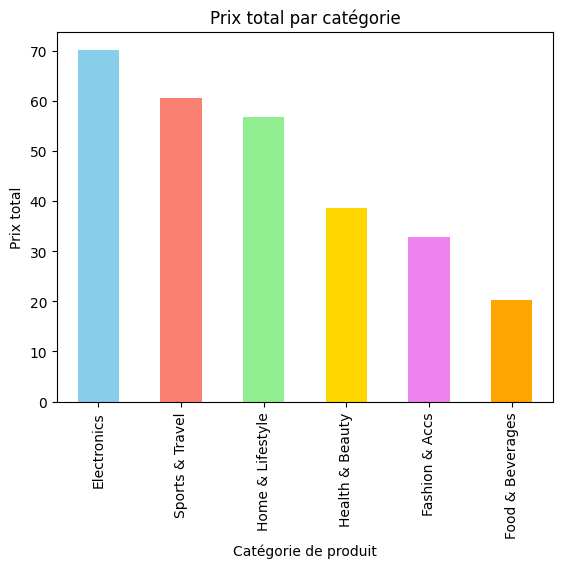

In [16]:
prix_par_catégorie = sales.groupby('Product line')['Unit price'].mean().sort_values(ascending=False)

prix_par_catégorie.plot(
    kind='bar',
    color=['skyblue','salmon','lightgreen','gold','violet','orange']
)

plt.title('Prix total par catégorie')
plt.ylabel('Prix total')
plt.xlabel('Catégorie de produit')

plt.show()


Ce graphique confirme notre analyse précédente, la rentabilité des produits liés à la maison et au mode de vie quotidien est expliquée par le prix et non la quantité vendue.(on voit que l'alimentation repr"sente les prix les plus faibles en moyenne)

C:\Users\diopd\AppData\Local\Temp\ipykernel_30384\4098388113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sales, x='Product line', y='Rating', palette='husl')


<Axes: xlabel='Product line', ylabel='Rating'>

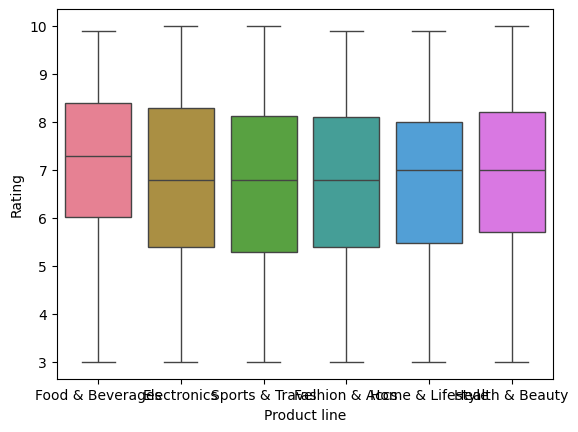

In [25]:
# Analyse Rating par catégorie
sns.boxplot(data=sales, x='Product line', y='Rating', palette='husl')

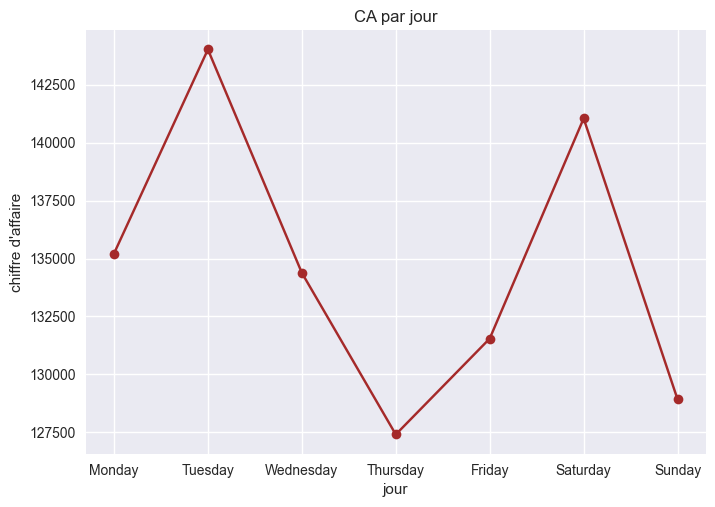

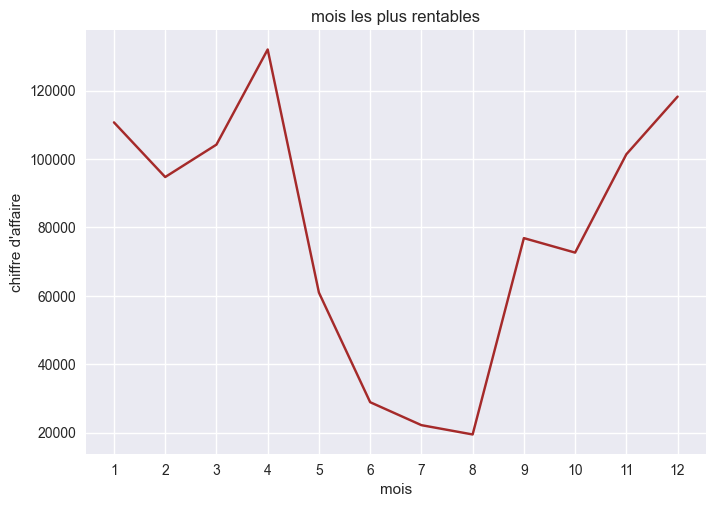

In [ ]:
plt.figure()

CA_jour = sales.groupby(sales['Date'].dt.day_name())['CA'].sum()

ordre_jours = [
    'Monday','Tuesday','Wednesday','Thursday',
    'Friday','Saturday','Sunday'
]
CA_jour = CA_jour.reindex(ordre_jours)

#plt.subplot (1,2,1)
CA_jour.plot(kind='line', marker= 'o', color='brown')
plt.title('CA par jour')
plt.xlabel('jour')
plt.ylabel("chiffre d'affaire")


plt.figure()
#plt.subplot (1,2,2)
CA_mois = sales.groupby(sales['Date'].dt.month)['CA'].sum()
CA_mois.plot(kind='line', color='brown')
plt.title('mois les plus rentables')
plt.xlabel('mois')
plt.ylabel("chiffre d'affaire")
plt.xticks(range(1,13))

plt.show()

C:\Users\diopd\AppData\Local\Temp\ipykernel_30384\4218139755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sales, x='Product line', y='Rating', palette='husl')


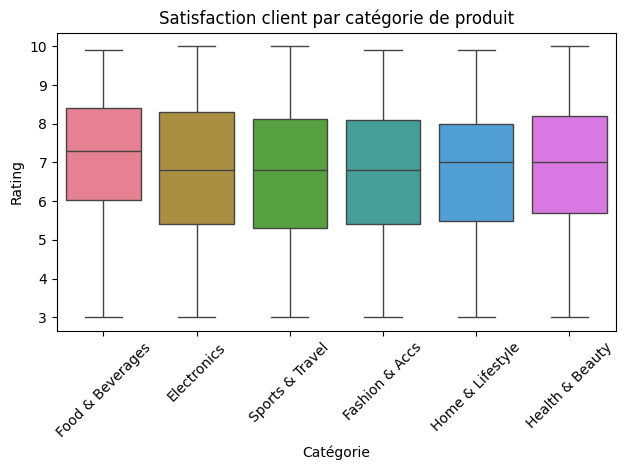

In [26]:
plt.figure()
sns.boxplot(data=sales, x='Product line', y='Rating', palette='husl')
plt.title('Satisfaction client par catégorie de produit')
plt.xlabel('Catégorie')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On voit que la catégorie alimentation a légérement la meilleure notation : **au moins 50% l'ont évalué à un peu plus de 7**. Mais globalement aucune catégorie ne se distingue vraiment.

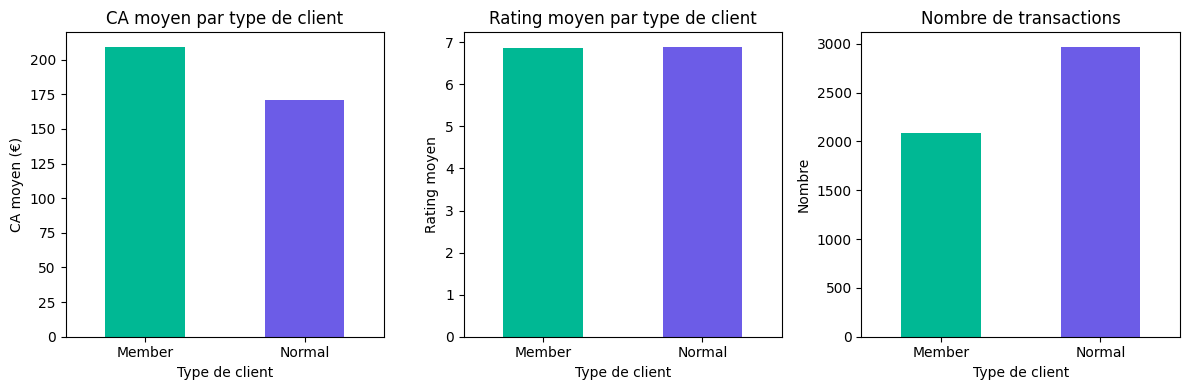

In [31]:

ordre = ['Member', 'Normal']
couleurs = ['#00B894', '#6C5CE7']

plt.figure(figsize=(12, 4))

# CA moyen
plt.subplot(1, 3, 1)
sales.groupby('Customer type')['CA'].mean().reindex(ordre).plot(
    kind='bar', color=couleurs)
plt.title('CA moyen par type de client')
plt.xlabel('Type de client')
plt.ylabel('CA moyen (€)')
plt.xticks(rotation=0)

# Rating moyen
plt.subplot(1, 3, 2)
sales.groupby('Customer type')['Rating'].mean().reindex(ordre).plot(
    kind='bar', color=couleurs)
plt.title('Rating moyen par type de client')
plt.xlabel('Type de client')
plt.ylabel('Rating moyen')
plt.xticks(rotation=0)

# Nombre de transactions
plt.subplot(1, 3, 3)
sales['Customer type'].value_counts().reindex(ordre).plot(
    kind='bar', color=couleurs)
plt.title('Nombre de transactions')
plt.xlabel('Type de client')
plt.ylabel('Nombre')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


- Les clients membres ont logiquement une influence plus marquée que les clients normaux sur le chiffre d'affaire.  
- Par contre, les clients normaux sont plus nombreux (3000 vs 2000 transactions)


# Conclusions et suggestions 

### Faits clés : 
- **CA total** : 187000 € sur l'année 2024
- **Catégorie la plus rentable** : Home & Lifestyle 
- **Catégorie la plus vendue** : Food & Beverages (volume)
- **Satisfaction moyenne** : 6.9/10 — niveau correct mais améliorable
- **Répartition équilibrée** : Genre, ville et mode de paiement similaires

### Recommandations
1. **Fidélisation** : convertir les clients normaux en membres
   → programme de fidélité, offres exclusives membres
2. **Pricing** : augmenter légèrement les prix Food & Beverages
   → catégorie très vendue mais moins rentable
3. **Satisfaction** : investiguer les catégories avec Rating < 6.5
   → enquêtes clients, amélioration du service